# Information-Driven Bars: Beyond Time Sampling

**Chapter 3: Market Microstructure**

**Docker image**: `ml4t`

## Purpose

Build the four bar families §3.4 walks through (time, tick, volume, dollar
plus imbalance/run information bars) from a single AAPL ITCH trading day,
compare their statistical properties (normality, autocorrelation), and
generate the Figure 3.4 sampling-comparison panel.

## Learning Objectives

After completing this notebook, you will be able to:
- Construct tick, volume, dollar, and imbalance bars from raw trades using
  `ml4t.engineer.bars` (vectorized polars + numba).
- Quantify the gain in normality (lower JB stat, lower kurtosis) when moving
  from time bars to volume/dollar bars.
- Apply Lee-Ready aggressor-side classification on ITCH (which lacks the
  aggressor field) and contrast tick-test vs midpoint-based imbalance bars.

## Book reference

Section §3.4, *The Art of Sampling: From Ticks to Bars*. Notebook generates
Figure 3.4 (2-hour window, 10:00-12:00 ET).

## Prerequisites

- Parsed ITCH `P`/`A`/`F`/`D`/`X`/`E`/`C`/`U` parquets at the canonical
  loader path (output of `01_itch_parser`). The Lee-Ready section
  reconstructs the LOB on the fly from these messages.

---

## Setup

In [1]:
"""Information-Driven Bars — constructing tick, volume, dollar, and imbalance bars from raw trades."""

import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from limit_orderbook import classify_trades_lee_ready

# ML4T Engineer - Bar samplers
from ml4t.engineer.bars import (
    DollarBarSampler,
    FixedTickImbalanceBarSampler,
    TickBarSampler,
    VolumeBarSampler,
)
from ml4t.engineer.bars.run import TickRunBarSampler
from scipy import stats

from data.equities.loader import load_nasdaq_itch
from utils.paths import get_output_dir

In [2]:
SYMBOL = "AAPL"
TRADING_DATE = "2020-01-30"
MAX_TRADES = 0  # 0 = all trades

In [3]:
sns.set_style("whitegrid")

# Normalize MAX_TRADES: 0 means no limit
if MAX_TRADES == 0:
    MAX_TRADES = None

In [4]:
# Input: Pre-parsed ITCH messages from canonical data location
MESSAGE_DIR = load_nasdaq_itch(get_base_path=True)

# Output: This notebook's bar outputs
OUTPUT_DIR = get_output_dir(3, "nasdaq_itch") / "bars"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Input directory (messages): {MESSAGE_DIR}")
print(f"Output directory (bars): {OUTPUT_DIR}")

# Validate parsed ITCH data — produced by 01_itch_parser or Rust parser
assert MESSAGE_DIR.exists(), (
    f"Parsed ITCH data not found at {MESSAGE_DIR}.\n"
    "Run the ITCH pipeline first:\n"
    "  1. Download: uv run python data/equities/market/microstructure/nasdaq_itch_download.py\n"
    "  2. Parse:    Run 01_itch_parser.py (Section 4) or Rust parser (Section 6)"
)
msg_types = sorted([d.name for d in MESSAGE_DIR.iterdir() if d.is_dir()])
assert "P" in msg_types, f"Trade messages (P) not found in {MESSAGE_DIR}. Available: {msg_types}"
print(f"\nAvailable message types: {msg_types}")

Input directory (messages): data/equities/market/microstructure/nasdaq_itch/messages
Output directory (bars): 03_market_microstructure/output/nasdaq_itch/bars

Available message types: ['A', 'C', 'D', 'E', 'F', 'H', 'I', 'J', 'K', 'L', 'P', 'Q', 'R', 'S', 'U', 'V', 'X', 'Y']


## 1. Load Trade Data from ITCH

We use trade messages (type 'P') from ITCH data. These represent actual
executions on the exchange, providing the raw tick stream for bar construction.

In [5]:
def load_itch_trades(symbol: str, max_trades: int | None = None) -> pl.DataFrame:
    """Load trade messages from ITCH parquet files, tick-test classified.

    Args:
        symbol: Stock symbol to filter
        max_trades: Maximum (chronological) trades to return

    The ml4t.engineer.bars module expects:
    - timestamp: datetime column
    - price: numeric price
    - volume: trade size
    - side: 1 for buyer-initiated, -1 for seller-initiated

    ITCH Trade (P) messages carry ``buy_sell_indicator='B'`` for *every*
    execution — the field reflects the resting (non-displayed) order's side,
    not the aggressor, so it cannot signal direction. We therefore infer the
    aggressor with the **tick test** (Lee & Ready 1991): an uptick is
    buyer-initiated (+1), a downtick seller-initiated (-1), and a zero-tick
    inherits the previous non-zero direction. This is the cheap ~78%-accurate
    classifier; §7 reconstructs the LOB for the ~94%-accurate Lee-Ready
    quote-midpoint version and contrasts the two.
    """
    trade_dir = MESSAGE_DIR / "P"
    assert trade_dir.exists(), f"No trade data at {trade_dir}"

    # Use lazy scan with predicate pushdown for efficiency
    # Filter is pushed down to parquet read, reducing memory
    df = (
        pl.scan_parquet(trade_dir / "*.parquet")
        .filter(pl.col("stock") == symbol)
        .collect()
        # The tick test is path-dependent, so classify on the chronological
        # stream (and take the first N chronological trades, not an arbitrary
        # parquet-order slice, when capped).
        .sort("timestamp")
        .with_columns((pl.col("price") / 10000).alias("price"))
    )
    if max_trades is not None:
        df = df.head(max_trades)

    # Tick test: sign of the price change, with zero-ticks carried forward from
    # the last directional trade. The very first trade has no predecessor, so it
    # defaults to buyer-initiated.
    trades = (
        df.with_columns(
            pl.when(pl.col("price").diff() > 0)
            .then(1)
            .when(pl.col("price").diff() < 0)
            .then(-1)
            .otherwise(None)
            .alias("side")
        )
        .with_columns(pl.col("side").forward_fill().fill_null(1).cast(pl.Int64))
        .select(
            [
                pl.col("timestamp"),
                pl.col("price"),
                pl.col("shares").alias("volume"),
                pl.col("side"),
            ]
        )
    )

    n_buy = trades.filter(pl.col("side") == 1).height
    n_sell = trades.filter(pl.col("side") == -1).height
    print(
        f"Tick-test classification: {n_buy:,} buyer-initiated, {n_sell:,} seller-initiated "
        f"({100 * n_sell / max(len(trades), 1):.1f}% sells)"
    )

    return trades

**Note**: The `classify_trades_lee_ready` function is imported from `utils.limit_orderbook` where
it shares the correct LOB reconstruction logic with `02_itch_lob_reconstruction`.
This ensures consistent order pool tracking and proper handling of Replace (U) chains.

In [6]:
# Load trades for our symbol
# Initialize variables for graceful handling when data missing
all_trades = None
trades = None
time_1m = None
tick_bars = None
volume_bars = None
dollar_bars = None
imbalance_bars = None
run_bars = None

if MESSAGE_DIR.exists():
    all_trades = load_itch_trades(SYMBOL, max_trades=MAX_TRADES)
    print(f"Symbol: {SYMBOL}")
    print(f"Trading Date: {TRADING_DATE}")
    print(f"Total trades: {len(all_trades):,}")

    if len(all_trades) > 0:
        print("\nSample:")
        print(all_trades.head(5))
        print("\nStats:")
        print(f"  Price range: ${all_trades['price'].min():.2f} - ${all_trades['price'].max():.2f}")
        print(f"  Total volume: {all_trades['volume'].sum():,.0f} shares")
        print(f"  Dollar volume: ${(all_trades['price'] * all_trades['volume']).sum():,.0f}")

Tick-test classification: 7,466 buyer-initiated, 7,648 seller-initiated (50.6% sells)
Symbol: AAPL
Trading Date: 2020-01-30
Total trades: 15,114

Sample:
shape: (5, 4)
┌───────────────────────────────┬───────┬────────┬──────┐
│ timestamp                     ┆ price ┆ volume ┆ side │
│ ---                           ┆ ---   ┆ ---    ┆ ---  │
│ datetime[ns]                  ┆ f64   ┆ u32    ┆ i64  │
╞═══════════════════════════════╪═══════╪════════╪══════╡
│ 2020-01-30 04:00:11.867450693 ┆ 321.2 ┆ 100    ┆ 1    │
│ 2020-01-30 04:01:41.874974414 ┆ 320.8 ┆ 67     ┆ -1   │
│ 2020-01-30 04:05:21.216347680 ┆ 320.8 ┆ 157    ┆ -1   │
│ 2020-01-30 04:06:43.861103674 ┆ 321.1 ┆ 95     ┆ 1    │
│ 2020-01-30 04:06:43.861143640 ┆ 321.1 ┆ 100    ┆ 1    │
└───────────────────────────────┴───────┴────────┴──────┘

Stats:
  Price range: $318.76 - $324.65
  Total volume: 1,056,628 shares
  Dollar volume: $339,797,921


In [7]:
# Filter to regular trading hours (9:30 AM - 4:00 PM ET)
# Note: ITCH timestamps are in US/Eastern (exchange local time), timezone-naive.
# This filter assumes the data is already in ET. For DST-aware filtering,
# you would need to localize timestamps first.
if all_trades is not None and len(all_trades) > 0:
    start_time = pd.Timestamp(f"{TRADING_DATE} 09:30:00")
    end_time = pd.Timestamp(f"{TRADING_DATE} 16:00:00")

    trades = all_trades.filter(
        (pl.col("timestamp") >= start_time) & (pl.col("timestamp") <= end_time)
    ).sort("timestamp")  # Must be sorted for group_by_dynamic

    print(f"\nTrades in regular hours: {len(trades):,}")
    print(f"Pre-market trades excluded: {len(all_trades) - len(trades):,}")


Trades in regular hours: 14,184
Pre-market trades excluded: 930


## 2. Create All Bar Types Using ml4t.engineer

The `ml4t.engineer.bars` module provides vectorized bar construction:
- **TickBarSampler**: Fixed number of trades per bar
- **VolumeBarSampler**: Fixed total volume per bar
- **DollarBarSampler**: Fixed dollar volume per bar
- **FixedTickImbalanceBarSampler**: Bars close when the signed tick imbalance
  exceeds a fixed threshold (stable; avoids the adaptive feedback loop)
- **TickRunBarSampler**: Bars close when a "run" of same-side trades exceeds expected length

The imbalance and run families are signed: they need a buyer/seller label per
trade. Here that label is the **tick test** computed at load time (§1); §7
rebuilds the imbalance family with the more accurate Lee-Ready quote-midpoint
classifier and contrasts the two.

In [8]:
if trades is not None and len(trades) > 0:
    print("Creating bars using ml4t.engineer...")

    # Time bars using Polars resample (standard approach)
    time_1m = (
        trades.group_by_dynamic("timestamp", every="1m")
        .agg(
            [
                pl.col("price").first().alias("open"),
                pl.col("price").max().alias("high"),
                pl.col("price").min().alias("low"),
                pl.col("price").last().alias("close"),
                pl.col("volume").sum().alias("volume"),
                pl.len().alias("tick_count"),
            ]
        )
        .drop_nulls()
    )
    print(f"Time bars (1-min): {len(time_1m):,}")

    # Tick bars - 100 trades per bar (AAPL has fewer trades than NVDA)
    tick_sampler = TickBarSampler(ticks_per_bar=100)
    tick_bars = tick_sampler.sample(trades)
    print(f"Tick bars (100): {len(tick_bars):,}")

    # Volume bars - 10K shares per bar (AAPL pre-split had ~$320 price)
    volume_sampler = VolumeBarSampler(volume_per_bar=10_000)
    volume_bars = volume_sampler.sample(trades)
    print(f"Volume bars (10K): {len(volume_bars):,}")

    # Dollar bars - $3M per bar (adjusted for ~$320 price)
    dollar_sampler = DollarBarSampler(dollars_per_bar=3_000_000)
    dollar_bars = dollar_sampler.sample(trades)
    print(f"Dollar bars ($3M): {len(dollar_bars):,}")

Creating bars using ml4t.engineer...
Time bars (1-min): 390
Tick bars (100): 141


Volume bars (10K): 96
Dollar bars ($3M): 102


In [9]:
# Imbalance bars - close when the signed tick imbalance exceeds a fixed threshold
# AFML tick-imbalance statistic: θ = Σ b_t (fixed threshold, not adaptive E[θ_T])
if trades is not None and len(trades) > 0:
    # A meaningful imbalance/run bar needs genuine two-sided flow. Require BOTH
    # directions to be present — an all-one-side stream (e.g. the raw ITCH
    # buy_sell_indicator before tick-test classification) would make signed
    # imbalance monotonic and degenerate the bars into near-tick bars.
    n_buy = trades.filter(pl.col("side") == 1).height
    n_sell = trades.filter(pl.col("side") == -1).height
    has_valid_sides = n_buy > 0 and n_sell > 0

    # Use a FIXED imbalance threshold rather than the adaptive (EWMA) sampler.
    # The adaptive E[θ_T] = E[T] × |2P[b=1] − 1| feeds back on its own bar
    # lengths and threshold-spirals on persistently one-sided flow — the
    # instability this section warns about. The fixed-threshold sampler the
    # library recommends for production is stable and reproducible. threshold=20
    # yields ~130 imbalance bars on this ~15k-trade AAPL day (comparable to the
    # volume/dollar bars above).
    if has_valid_sides:
        imbalance_sampler = FixedTickImbalanceBarSampler(threshold=20)
        imbalance_bars = imbalance_sampler.sample(trades)
        print(f"Tick imbalance bars: {len(imbalance_bars):,}")
    else:
        print("Imbalance bars skipped (insufficient side attribution in trade data)")
        imbalance_bars = pl.DataFrame()

Tick imbalance bars: 124


In [10]:
# Run bars - close when cumulative run count exceeds expected threshold
# AFML formula: θ = max(cumulative_buys, cumulative_sells)
# Bars form when one side dominates, signaling sustained directional flow
if trades is not None and len(trades) > 0 and has_valid_sides:
    try:
        run_sampler = TickRunBarSampler(
            expected_ticks_per_bar=50,  # Initial E[T]
            alpha=0.001,  # small EWMA decay: keeps the adaptive threshold stable
        )
        run_bars = run_sampler.sample(trades)
        print(f"Tick run bars: {len(run_bars):,}")
    except Exception as e:
        print(f"Run bars skipped (requires trade direction): {e}")
        run_bars = pl.DataFrame()
elif trades is not None and len(trades) > 0:
    print("Run bars skipped (insufficient side attribution in trade data)")
    run_bars = pl.DataFrame()

Tick run bars: 359


## 3. Compare Statistical Properties

We compare key properties that affect ML model performance:
- **Return distribution**: Closer to normal is better
- **Autocorrelation**: Lower is better (more IID)
- **Heteroskedasticity**: More stable variance is better

In [11]:
def analyze_returns(bars: pl.DataFrame, bar_type: str) -> dict | None:
    """Analyze return statistics for a bar type."""
    if "close" not in bars.columns or len(bars) < 10:
        return None

    # Convert to pandas for scipy stats
    returns = bars["close"].pct_change().drop_nulls().to_numpy()

    if len(returns) < 10:
        return None

    # Normality test (Jarque-Bera)
    jb_stat, jb_pval = stats.jarque_bera(returns)

    # Autocorrelation at lag 1
    autocorr = np.corrcoef(returns[:-1], returns[1:])[0, 1] if len(returns) > 1 else 0

    return {
        "bar_type": bar_type,
        "n_bars": len(bars),
        "mean_return": np.mean(returns) * 100,
        "std_return": np.std(returns) * 100,
        "skewness": stats.skew(returns),
        "kurtosis": stats.kurtosis(returns),
        "jb_stat": jb_stat,
        "jb_pval": jb_pval,
        "autocorr_1": autocorr,
    }

In [12]:
if time_1m is not None:
    # Analyze all bar types
    results = []

    bar_list = [
        (time_1m, "Time (1-min)"),
        (tick_bars, "Tick (100)"),
        (volume_bars, "Volume (10K)"),
        (dollar_bars, "Dollar ($3M)"),
        (imbalance_bars, "Imbalance"),
    ]
    # Add run bars if available
    if run_bars is not None and len(run_bars) > 0:
        bar_list.append((run_bars, "Run"))

    for bars, name in bar_list:
        result = analyze_returns(bars, name)
        if result:
            results.append(result)

    stats_df = pd.DataFrame(results).set_index("bar_type")
    print("\n=== Statistical Properties Comparison ===\n")
    print(stats_df.round(4).to_string())


=== Statistical Properties Comparison ===

              n_bars  mean_return  std_return  skewness  kurtosis   jb_stat  jb_pval  autocorr_1
bar_type                                                                                        
Time (1-min)     390       0.0022      0.0644   -0.4973    6.0486  609.0256   0.0000     -0.0227
Tick (100)       141       0.0077      0.1104   -0.0706    1.0385    6.4074   0.0406      0.1528
Volume (10K)      96       0.0113      0.1422   -0.2687    0.4511    1.9489   0.3774      0.0260
Dollar ($3M)     102       0.0103      0.1372   -0.3269    0.2987    2.1743   0.3372     -0.0273
Imbalance        124       0.0085      0.1197   -0.6202    1.9908   28.1953   0.0000      0.0135
Run              359       0.0029      0.0695    0.1350    0.7799   10.1596   0.0062      0.0397


### Interpretation

| Metric | Meaning | Better Value |
|--------|---------|--------------|
| JB Stat | Distance from normality | Lower |
| Autocorr | Serial dependence | Closer to 0 |
| Kurtosis | Fat tails (excess over 3) | Lower |

## 4. Visualize Return Distributions

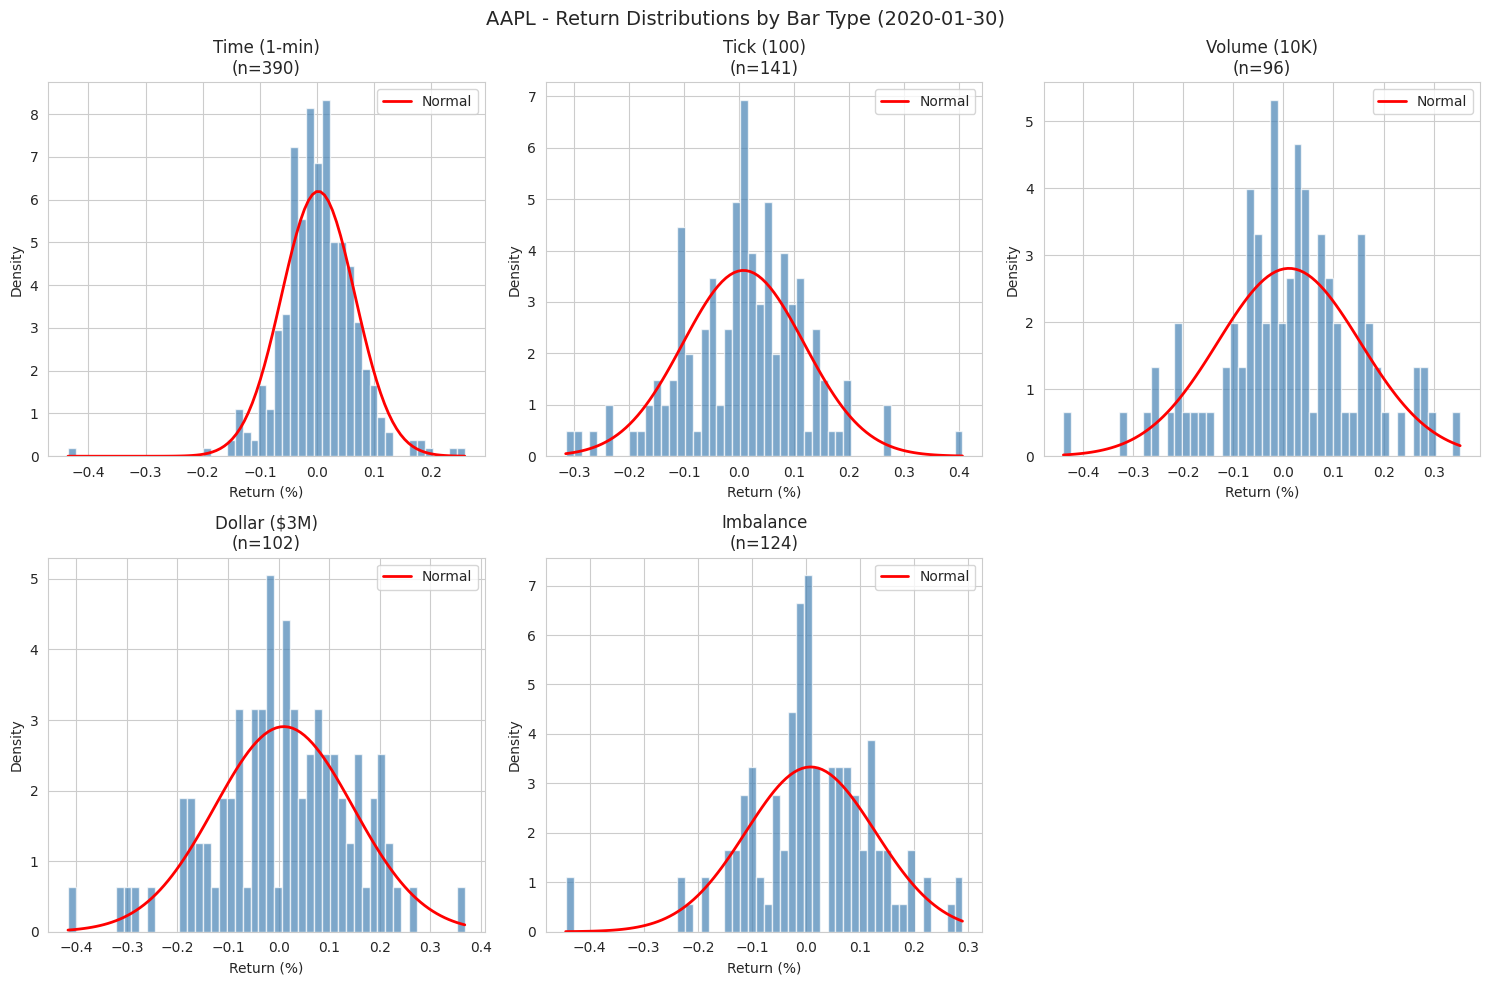

In [13]:
if time_1m is not None:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    bar_types = [
        (time_1m, "Time (1-min)"),
        (tick_bars, "Tick (100)"),
        (volume_bars, "Volume (10K)"),
        (dollar_bars, "Dollar ($3M)"),
        (imbalance_bars, "Imbalance"),
    ]

    for i, (bars, name) in enumerate(bar_types):
        ax = axes[i]
        if "close" in bars.columns and len(bars) > 10:
            returns = bars["close"].pct_change().drop_nulls().to_numpy() * 100
            returns = returns[(returns > -2) & (returns < 2)]  # Clip outliers

            if len(returns) > 5:
                ax.hist(returns, bins=50, density=True, alpha=0.7, color="steelblue")

                # Overlay normal distribution
                x = np.linspace(returns.min(), returns.max(), 100)
                ax.plot(
                    x,
                    stats.norm.pdf(x, returns.mean(), returns.std()),
                    "r-",
                    linewidth=2,
                    label="Normal",
                )

            ax.set_title(f"{name}\n(n={len(bars):,})")
            ax.set_xlabel("Return (%)")
            ax.set_ylabel("Density")
            ax.legend()

    # Hide empty subplot
    axes[5].axis("off")

    plt.suptitle(f"{SYMBOL} - Return Distributions by Bar Type ({TRADING_DATE})", fontsize=14)
    plt.tight_layout()
    plt.show()

## 5. Bar Duration Analysis

Information-driven bars have variable duration - they are faster during
high activity periods and slower during quiet periods.

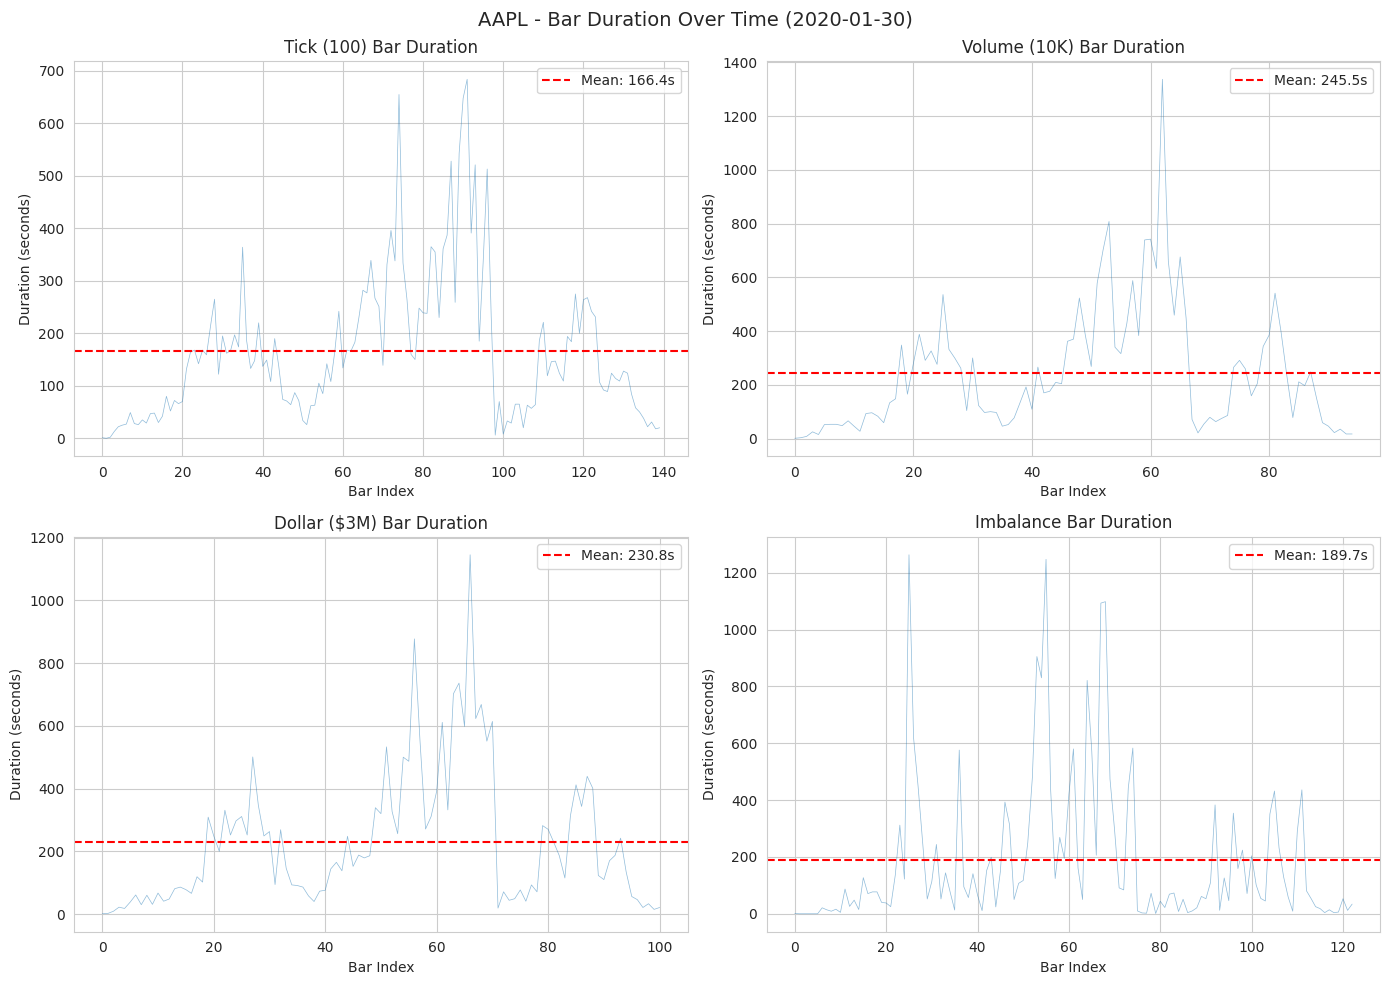

In [14]:
if tick_bars is not None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    bar_types = [
        (tick_bars, "Tick (100)"),
        (volume_bars, "Volume (10K)"),
        (dollar_bars, "Dollar ($3M)"),
        (imbalance_bars, "Imbalance"),
    ]

    for i, (bars, name) in enumerate(bar_types):
        ax = axes[i // 2, i % 2]

        # Calculate duration between bars
        timestamps = bars["timestamp"].to_numpy()
        if len(timestamps) > 1:
            durations = np.diff(timestamps).astype("timedelta64[s]").astype(float)

            ax.plot(range(len(durations)), durations, alpha=0.5, linewidth=0.5)
            ax.axhline(
                np.mean(durations),
                color="red",
                linestyle="--",
                label=f"Mean: {np.mean(durations):.1f}s",
            )

            ax.set_title(f"{name} Bar Duration")
            ax.set_xlabel("Bar Index")
            ax.set_ylabel("Duration (seconds)")
            ax.legend()

    plt.suptitle(f"{SYMBOL} - Bar Duration Over Time ({TRADING_DATE})", fontsize=14)
    plt.tight_layout()
    plt.show()

## 6. Buy/Sell Volume Decomposition

The ml4t.engineer bar samplers track buy and sell volume separately from the
per-trade `side` label. Because **ITCH Trade (P) messages do not carry true
aggressor direction** — the `buy_sell_indicator` field is uniformly 'B' for
every trade in this dataset — the decomposition below rests on the **tick-test**
classification from §1, not an exchange-provided aggressor field. Treat it as a
~78%-accurate proxy.

More accurate alternatives:
- **Lee-Ready algorithm**: compare trade price to quote midpoint (§7 below)
- **Order matching**: track which book side was reduced by execution
- **DataBento MBO+MBP-1**: harmonized data with a true trade-direction field

In [15]:
if volume_bars is not None and "buy_volume" in volume_bars.columns:
    # Check if we have actual buy/sell variance
    volume_bars_pd = volume_bars.to_pandas()
    has_sell_volume = volume_bars_pd["sell_volume"].sum() > 0

    if has_sell_volume:
        print("=== Order Flow Analysis ===\n")

        # Compute signed imbalance in [-1, 1]. buy_volume/sell_volume are unsigned
        # (uint32), so cast to float BEFORE subtracting — an unsigned difference
        # underflows to ~2^32 on every sell-dominated bar.
        buy_v = volume_bars_pd["buy_volume"].astype("float64")
        sell_v = volume_bars_pd["sell_volume"].astype("float64")
        volume_bars_pd["imbalance"] = (buy_v - sell_v) / (buy_v + sell_v)

        print(f"Mean imbalance: {volume_bars_pd['imbalance'].mean():.4f}")
        print(f"Std imbalance: {volume_bars_pd['imbalance'].std():.4f}")
    else:
        print("=== Order Flow Analysis ===\n")
        print("WARNING: ITCH Trade (P) messages do not provide aggressor direction.")
        print("   All trades show buy_sell_indicator='B' uniformly.")
        print("\nSee Section 7 below for Lee-Ready classification using LOB midpoint.")

=== Order Flow Analysis ===

Mean imbalance: -0.0202
Std imbalance: 0.2523


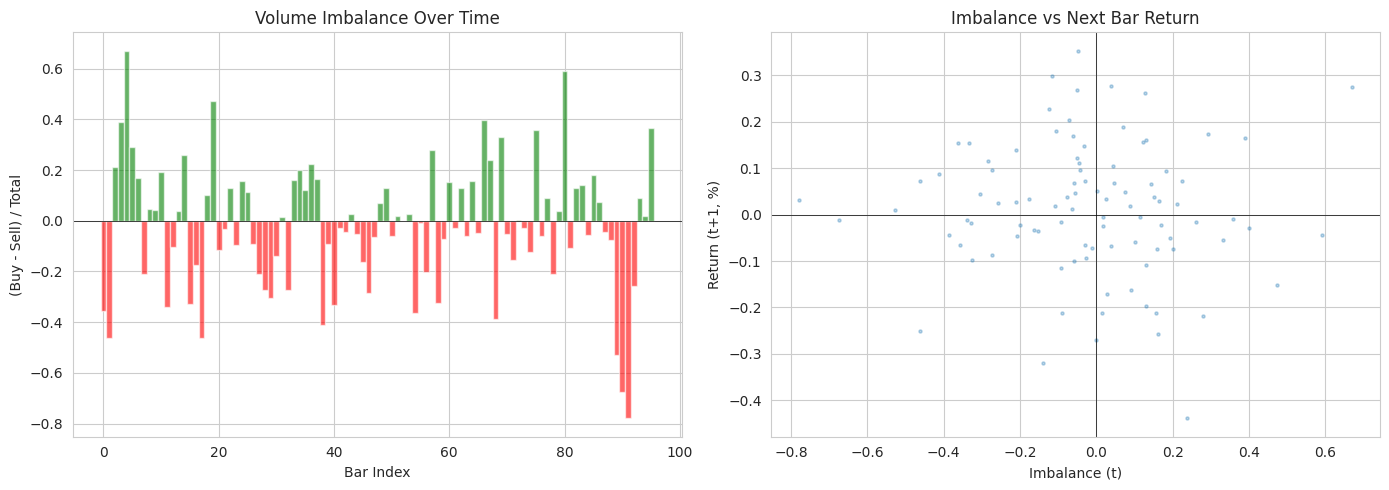

In [16]:
if volume_bars is not None and "buy_volume" in volume_bars.columns:
    if volume_bars_pd["sell_volume"].sum() > 0:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Imbalance over time
        ax = axes[0]
        colors = ["green" if x > 0 else "red" for x in volume_bars_pd["imbalance"]]
        ax.bar(
            range(len(volume_bars_pd)),
            volume_bars_pd["imbalance"],
            color=colors,
            alpha=0.6,
            width=1.0,
        )
        ax.axhline(0, color="black", linewidth=0.5)
        ax.set_title("Volume Imbalance Over Time")
        ax.set_xlabel("Bar Index")
        ax.set_ylabel("(Buy - Sell) / Total")

        # Imbalance vs returns
        ax = axes[1]
        volume_bars_pd["return"] = volume_bars_pd["close"].pct_change()
        ax.scatter(
            volume_bars_pd["imbalance"].iloc[:-1],
            volume_bars_pd["return"].iloc[1:] * 100,
            alpha=0.3,
            s=5,
        )
        ax.axhline(0, color="black", linewidth=0.5)
        ax.axvline(0, color="black", linewidth=0.5)
        ax.set_title("Imbalance vs Next Bar Return")
        ax.set_xlabel("Imbalance (t)")
        ax.set_ylabel("Return (t+1, %)")

        plt.tight_layout()
        plt.show()

## 7. Lee-Ready Trade Classification

Since ITCH Trade (P) messages don't provide aggressor direction, we implement
the **Lee-Ready algorithm** to classify trades. **Validated accuracy: ~94%**
(compared to ~78% for tick-test alone; see `15_itch_lee_ready` for details).

**Quote test** (primary):
- Compare trade price to midpoint of best bid/ask
- Price > midpoint → buy-initiated
- Price < midpoint → sell-initiated

**Tick test** (fallback for trades at midpoint):
- Uptick from previous trade → buy
- Downtick → sell
- Zero tick → use last tick direction

**Why tick-test alone fails**: 83% of consecutive trades have the same price.
The continuous tick test carries forward the previous direction, but errors
propagate and decorrelate from actual aggressor intent.

This requires reconstructing the LOB state at each trade timestamp—see
`02_itch_lob_reconstruction` for the complete LOB state machine.

In [17]:
# Lee-Ready classification (slower but accurate)
# Only run in full mode due to computational cost
lee_ready_trades = None
lee_ready_imbalance_bars = None

if MESSAGE_DIR.exists():
    print("=== Lee-Ready Classification ===\n")
    print("Reconstructing LOB state to classify trades by quote midpoint...")
    print("(Using shared utils.limit_orderbook with correct order pool tracking)\n")

    try:
        # Use shared function from utils.limit_orderbook with proper LOB reconstruction
        # Filter to regular trading hours (9:30 AM - 4:00 PM)
        from datetime import datetime

        start_time = datetime.strptime(f"{TRADING_DATE} 09:30:00", "%Y-%m-%d %H:%M:%S")
        end_time = datetime.strptime(f"{TRADING_DATE} 16:00:00", "%Y-%m-%d %H:%M:%S")

        lee_ready_trades = classify_trades_lee_ready(
            itch_dir=MESSAGE_DIR,
            symbol=SYMBOL,
            start_time=start_time,
            end_time=end_time,
        )

        # Rename 'shares' to 'volume' for ImbalanceBarSampler compatibility
        if lee_ready_trades is not None and len(lee_ready_trades) > 0:
            lee_ready_trades = lee_ready_trades.rename({"shares": "volume"})

    except Exception as e:
        print(f"Lee-Ready classification failed: {e}")
        print("This requires complete ITCH data (A, D, E, X, P messages).")

=== Lee-Ready Classification ===

Reconstructing LOB state to classify trades by quote midpoint...
(Using shared utils.limit_orderbook with correct order pool tracking)



Processing 1,956,673 messages for Lee-Ready classification...


Lee-Ready:   0%|          | 0/1956673 [00:00<?, ?it/s]

Classified 14,184 trades
  Buys: 6,842 (48.2%)
  Sells: 7,342 (51.8%)


In [18]:
if lee_ready_trades is not None and len(lee_ready_trades) > 0:
    # Build imbalance bars with Lee-Ready classification
    usable = lee_ready_trades.filter(pl.col("side") != 0)
    if len(usable) > len(lee_ready_trades) * 0.5:
        print("\nBuilding tick imbalance bars with Lee-Ready classification...")
        # Same sampler (fixed threshold=20) as the §2 tick-test imbalance bars so
        # the comparison below isolates the classification method, not the binning.
        imb_sampler = FixedTickImbalanceBarSampler(threshold=20)
        lee_ready_imbalance_bars = imb_sampler.sample(lee_ready_trades)
        print(f"Lee-Ready Imbalance bars: {len(lee_ready_imbalance_bars):,}")

        # Compare to tick-test imbalance bars
        if imbalance_bars is not None:
            print("\n=== Classification Method Comparison ===")
            print(f"Tick-test imbalance bars: {len(imbalance_bars):,}")
            print(f"Lee-Ready imbalance bars: {len(lee_ready_imbalance_bars):,}")

            # Compare JB stats
            from scipy import stats as sp_stats

            def jb_stat(bars):
                closes = bars["close"].to_numpy()
                returns = np.diff(np.log(closes))
                return sp_stats.jarque_bera(returns)[0]

            tick_jb = jb_stat(imbalance_bars) if len(imbalance_bars) > 30 else None
            lr_jb = (
                jb_stat(lee_ready_imbalance_bars) if len(lee_ready_imbalance_bars) > 30 else None
            )

            if tick_jb and lr_jb:
                # Lower Jarque-Bera = closer to normal. Report both and let
                # the difference speak for itself.
                diff = abs(lr_jb - tick_jb)
                closer = "Lee-Ready" if lr_jb < tick_jb else "Tick-test"
                print("\nJarque-Bera (lower = closer to normal):")
                print(f"  Tick-test: {tick_jb:.1f}")
                print(f"  Lee-Ready: {lr_jb:.1f}")
                print(f"  Difference: {diff:.1f} (closer to normal: {closer})")


Building tick imbalance bars with Lee-Ready classification...
Lee-Ready Imbalance bars: 147

=== Classification Method Comparison ===
Tick-test imbalance bars: 124
Lee-Ready imbalance bars: 147

Jarque-Bera (lower = closer to normal):
  Tick-test: 28.7
  Lee-Ready: 74.5
  Difference: 45.8 (closer to normal: Tick-test)


## 8. Intraday Pattern Analysis

ITCH data captures the full trading day, allowing us to analyze
intraday patterns in bar formation.

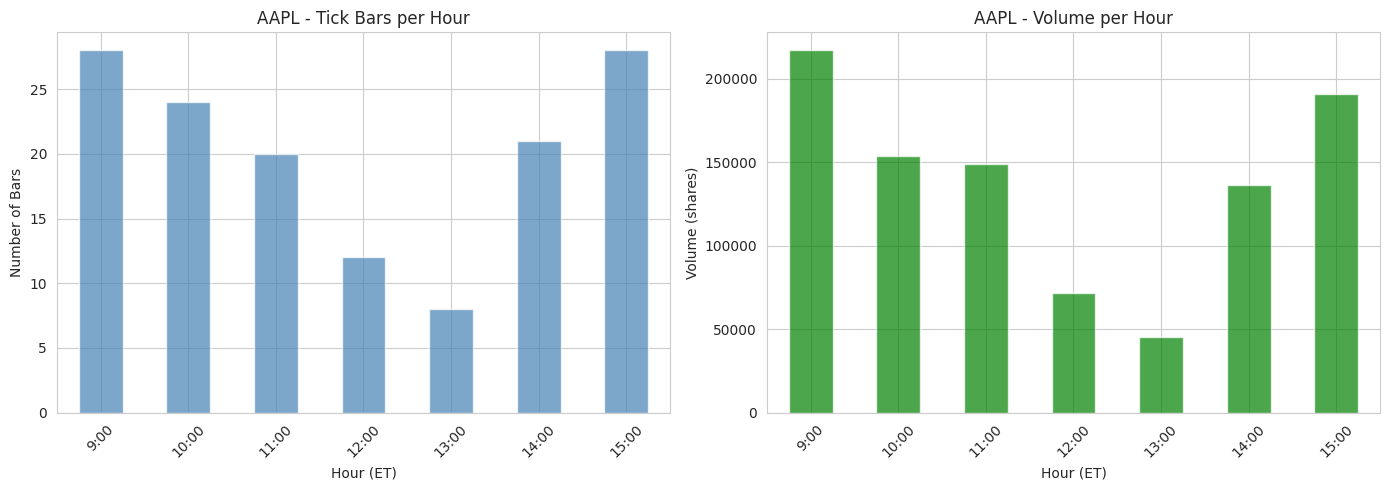


Intraday Pattern (U-shape expected):
Opening hour typically has highest activity due to overnight information processing.
Closing hour has high activity due to portfolio rebalancing and MOC orders.


In [19]:
if tick_bars is not None and len(tick_bars) > 0:
    # Add hour column
    tick_bars_pd = tick_bars.to_pandas()
    tick_bars_pd["hour"] = tick_bars_pd["timestamp"].dt.hour

    # Count bars per hour
    bars_per_hour = tick_bars_pd.groupby("hour").size()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Bars per hour
    ax = axes[0]
    bars_per_hour.plot(kind="bar", ax=ax, color="steelblue", alpha=0.7)
    ax.set_title(f"{SYMBOL} - Tick Bars per Hour")
    ax.set_xlabel("Hour (ET)")
    ax.set_ylabel("Number of Bars")
    ax.set_xticklabels([f"{h}:00" for h in bars_per_hour.index], rotation=45)

    # Volume per hour
    ax = axes[1]
    volume_per_hour = tick_bars_pd.groupby("hour")["volume"].sum()
    volume_per_hour.plot(kind="bar", ax=ax, color="green", alpha=0.7)
    ax.set_title(f"{SYMBOL} - Volume per Hour")
    ax.set_xlabel("Hour (ET)")
    ax.set_ylabel("Volume (shares)")
    ax.set_xticklabels([f"{h}:00" for h in volume_per_hour.index], rotation=45)

    plt.tight_layout()
    plt.show()

    print("\nIntraday Pattern (U-shape expected):")
    print("Opening hour typically has highest activity due to overnight information processing.")
    print("Closing hour has high activity due to portfolio rebalancing and MOC orders.")

## 9. Save Results

In [20]:
if time_1m is not None:
    # Save bar data
    bar_outputs = [
        (time_1m, "time_1m"),
        (tick_bars, "tick_100"),
        (volume_bars, "volume_10k"),
        (dollar_bars, "dollar_3m"),
        (imbalance_bars, "imbalance_tick"),
        (lee_ready_imbalance_bars, "imbalance_lee_ready"),
    ]
    for bars, name in bar_outputs:
        if bars is not None and len(bars) > 0:
            output_file = OUTPUT_DIR / f"{SYMBOL}_{name}_bars.parquet"
            bars.write_parquet(output_file)
            print(f"Saved: {output_file.name}")

Saved: AAPL_time_1m_bars.parquet
Saved: AAPL_tick_100_bars.parquet
Saved: AAPL_volume_10k_bars.parquet
Saved: AAPL_dollar_3m_bars.parquet
Saved: AAPL_imbalance_tick_bars.parquet
Saved: AAPL_imbalance_lee_ready_bars.parquet


## Key Takeaways

### Bar Type Selection Guidelines

| Bar Type | Best For | Pros | Cons |
|----------|----------|------|------|
| **Time** | Calendar alignment | Simple, universal | Unequal information |
| **Tick** | Order flow analysis | Equal trades | Ignores size |
| **Volume** | Activity sampling | Size-weighted | Irregular timing |
| **Dollar** | Economic activity | Price-adjusted | Complex to compute |
| **Imbalance** | Informed trading | Captures signals | Parameter-sensitive |

### Trade Classification Methods (Validated Accuracy)

| Method | Accuracy | Coverage | Data Required | Use Case |
|--------|----------|----------|---------------|----------|
| **Direct aggressor** | 100% | 100% | DataBento MBO, CME FIX | Production systems |
| **Lee-Ready** | **~94%** | 100% | LOB + trades | ITCH reconstruction |
| **Tick test only** | **~78%** | 100% | Trade prices only | Weak fallback |

**Critical finding**: The tick test alone (~78% accuracy) substantially underperforms
Lee-Ready (~94%). Zero-tick trades (same price as previous) propagate classification
errors. Do not use tick-test alone for imbalance bars.

Lee-Ready achieves ~94% accuracy by using LOB midpoint for classification,
falling back to tick-test only for the minority of trades at the midpoint.
Direct aggressor field (DataBento, CME) is always preferred when available.
See `15_itch_lee_ready` for full multi-day validation results.

### ITCH Data Advantages

1. **Complete day coverage**: All stocks, all messages for entire trading day
2. **Message-level granularity**: See every order add, cancel, execute
3. **Free sample data**: NASDAQ provides sample files for research
4. **Lee-Ready possible**: Can reconstruct LOB for trade classification

### ml4t.engineer Bar Library

1. **Vectorized**: 10,000+ rows/sec with Polars/Numba on the comparison run above
2. **Buy/Sell tracking**: Order-flow decomposition built into the bar output
3. **Consistent API**: Same interface for tick, volume, dollar, and imbalance bars
4. **Typed and tested**: type hints throughout; covered by the library's test suite

---

**Reference**: López de Prado, M. (2018). *Advances in Financial Machine Learning*. Wiley.